# LeetCode #104: Maximum Depth of Binary Tree

https://leetcode.com/problems/maximum-depth-of-binary-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| BFS Level Count | O(n) | O(n) | Count BFS iterations |
| Iterative DFS (Stack) | O(n) | O(n) | Track (node, depth) on stack |
| **DFS Recursive ★** | **O(n)** | **O(n)** | `1 + max(left, right)` — cleanest |

---

## Understanding the Methods

### Brute Force (BFS)
Use a BFS queue. Count how many levels we process. Each complete level iteration increments a counter. Return the counter.

### DFS Recursive (Optimal ★)
The key insight: `maxDepth(node) = 1 + max(maxDepth(node.left), maxDepth(node.right))`. Base case: null node returns 0. This naturally bubbles the maximum depth up from leaves to root.

## Constraints
- Number of nodes: [0, 10⁴]
- Node values: [-100, 100]

## Solutions

### C#

In [ ]:
public class Solution {
    public int MaxDepth(TreeNode root) {
        if (root == null) return 0;
        return 1 + Math.Max(MaxDepth(root.left), MaxDepth(root.right));
    }
}

### Python

In [ ]:
class Solution:
    def maxDepth(self, root) -> int:
        if not root:
            return 0
        return 1 + max(self.maxDepth(root.left), self.maxDepth(root.right))

### Go

In [ ]:
func maxDepth(root *TreeNode) int {
    if root == nil { return 0 }
    left  := maxDepth(root.Left)
    right := maxDepth(root.Right)
    if left > right { return 1 + left }
    return 1 + right
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn max_depth(root: Option<Rc<RefCell<TreeNode>>>) -> i32 {
        match root {
            None => 0,
            Some(node) => {
                let left  = Self::max_depth(node.borrow().left.clone());
                let right = Self::max_depth(node.borrow().right.clone());
                1 + left.max(right)
            }
        }
    }
}

## Example Scenarios

### 1. Common Case — Balanced 3-Level Tree
**Input:** `root = [3, 9, 20, null, null, 15, 7]`

Recurse: maxDepth(3) = 1 + max(maxDepth(9), maxDepth(20)). maxDepth(9) = 1 + max(0, 0) = 1. maxDepth(20) = 1 + max(1, 1) = 2. Result: 1 + max(1, 2) = 3.

*Why tricky:* Baseline. The right subtree is deeper; the $\max()$ picks it. Confirms the formula $d(v) = 1 + \max(d(v_L), d(v_R))$.

$d(root) = 1 + \max(1, 2) = 3$

**Output:** `3`

### 2. Slightly Complex — Left-Heavy Unbalanced Tree
**Input:** `root = [1, 2, 3, 4, null, null, null, 5]`

Deepest path: 1 → 2 → 4 → 5 (depth 4). Right subtree (node 3) has depth 1. The recursive max() at each level picks the left branch. Node 3 is a "decoy" short branch.

*Why tricky:* Unbalanced tree where the deepest leaf is far-left. Tests that both subtrees are fully explored, not just the first child visited. An early-return optimization would miss the deep left path.

$d = 4$, right subtree depth $= 1$ (decoy)

**Output:** `4`

### 3. Edge Case: Time Factor — Right-Skewed Chain (10000 Nodes)
**Input:** `root = 10000-node right-only chain, values 1..10000` (max constraint)

Every node has only a right child. Recursion goes $n = 10000$ levels deep. Each call does $O(1)$ work, total $O(n)$. The answer is at the very end, forcing a full traversal.

*Why tricky:* Maximum $n = 10^4$. Recursion stack = 10000 frames. In Python (default recursion limit ~1000), this causes `RecursionError` — requires `sys.setrecursionlimit` or iterative approach.

$T = O(n) = O(10000)$, stack depth $= 10000$

**Output:** `10000`

### 4. Edge Case: Space Factor — Perfect Binary Tree (10000 Nodes)
**Input:** `root = near-perfect tree, ~10000 nodes, depth $\approx 14$`

Balanced tree: recursion stack only goes $\lceil\log_2(10001)\rceil = 14$ frames deep. Same $n$, vastly different space from Example 3. Time is still $O(n)$ since every node is visited.

*Why tricky:* Best case for space: stack = $O(\log n) \approx 14$. Contrast with Ex 3 where stack = $O(n) = 10000$. Same total work, same $n$, but tree shape determines space.

$\text{Skewed: } S = O(n)$ vs $\text{Balanced: } S = O(\log n)$

**Output:** `~14`

### 5. Almost-Impossible but Plausible — Empty Tree (null root)
**Input:** `root = null`

Base case fires immediately: null → return 0. No recursion occurs. This is the boundary value $n = 0$.

*Why tricky:* Zero-node tree is an extreme boundary. Off-by-one bugs (returning 1 for null, or crashing on `null.left`) surface here. The answer is 0, not 1 — a common mistake when depth vs. height definitions differ.

$d(\text{null}) = 0$, not $1$

**Output:** `0`

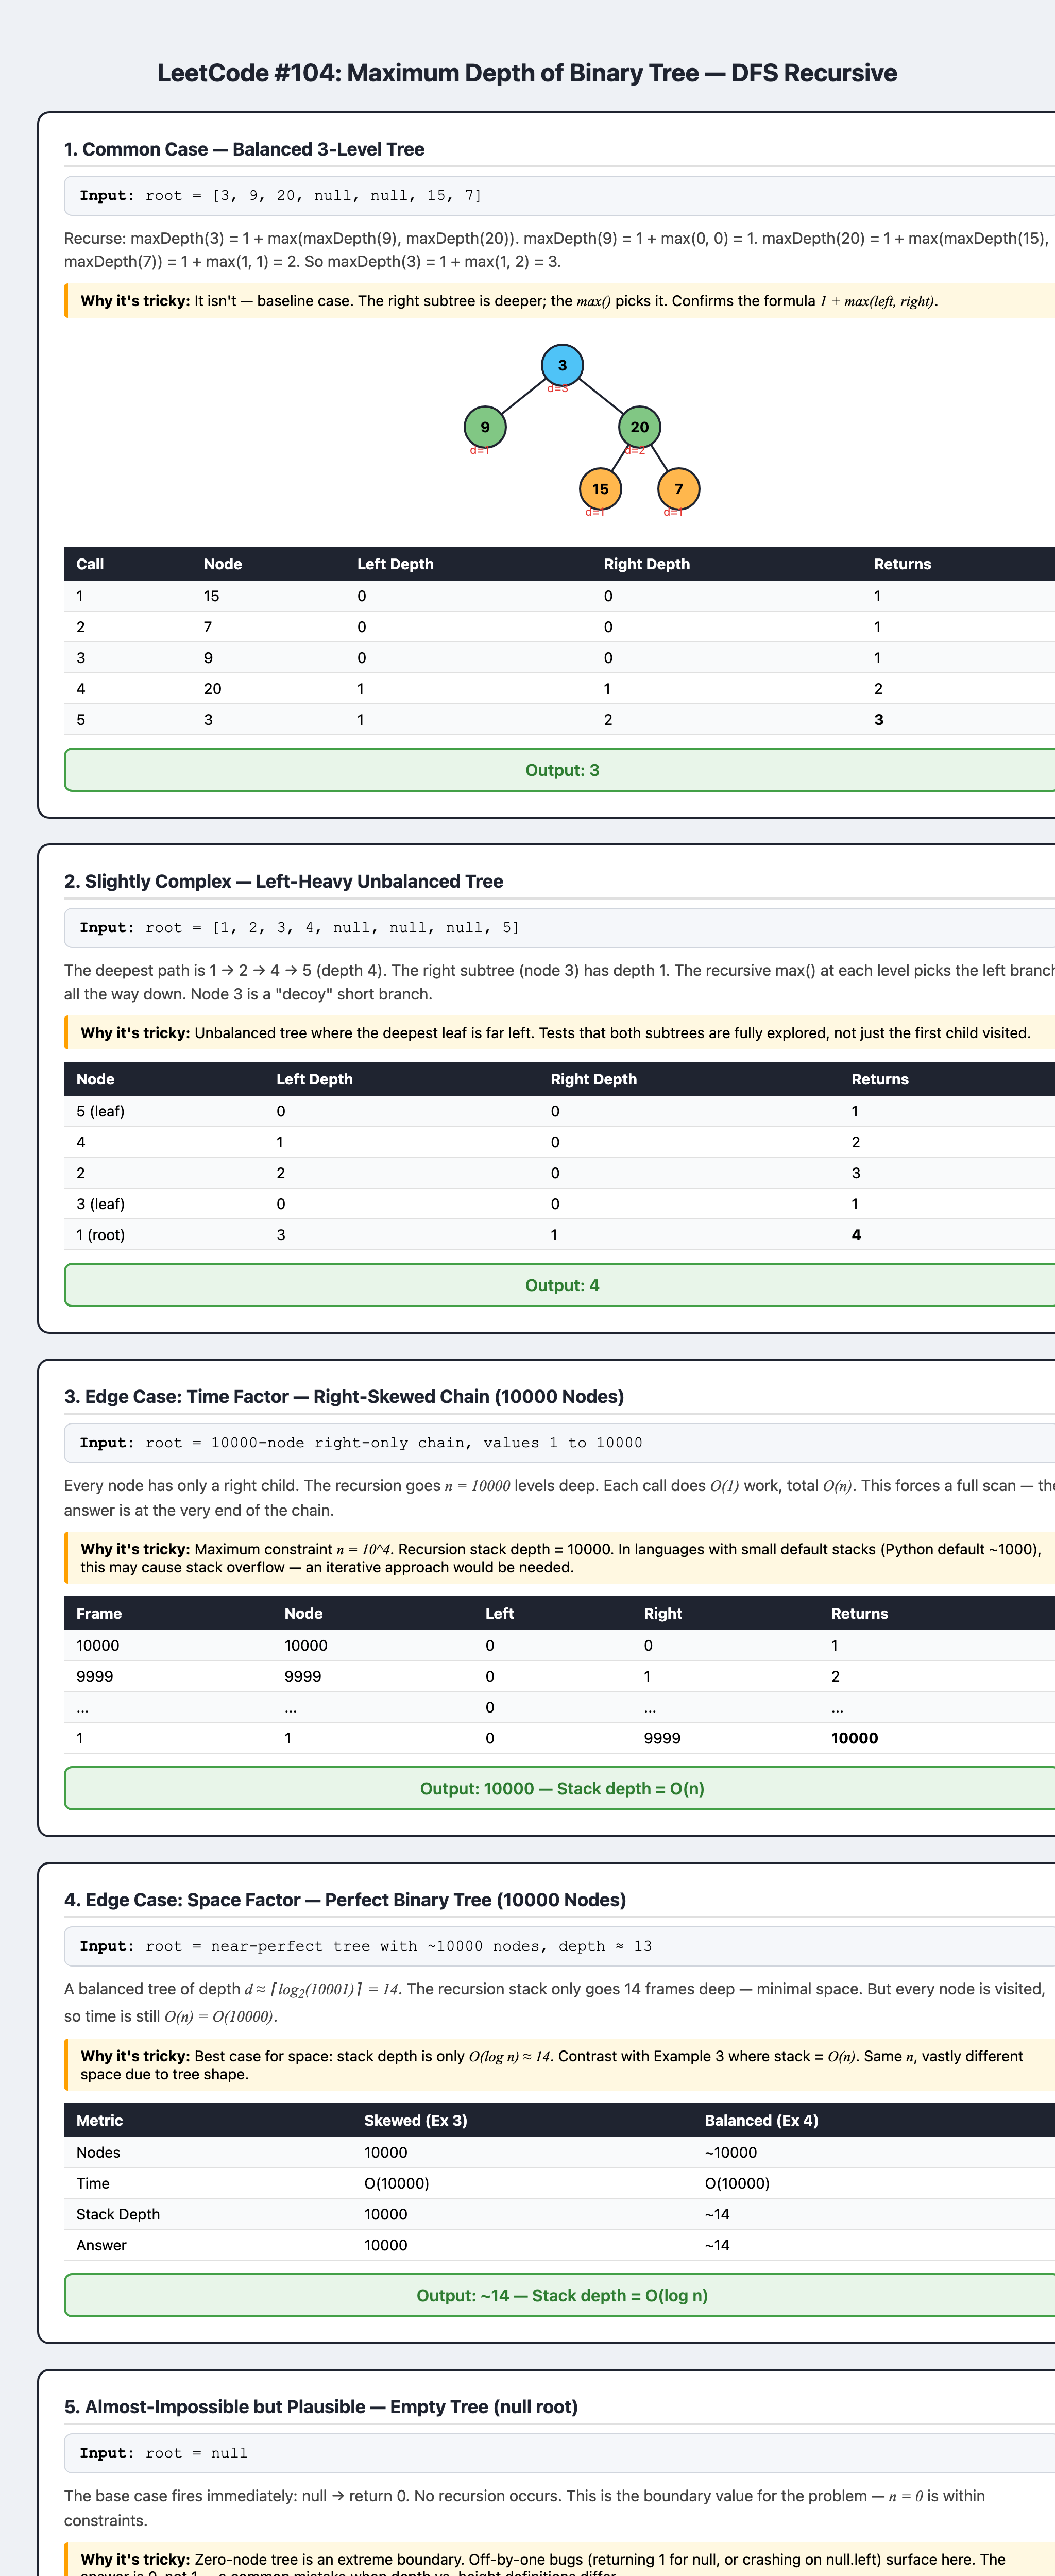